In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
df = pd.read_csv('ToyotaCorolla - MLR.csv')
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


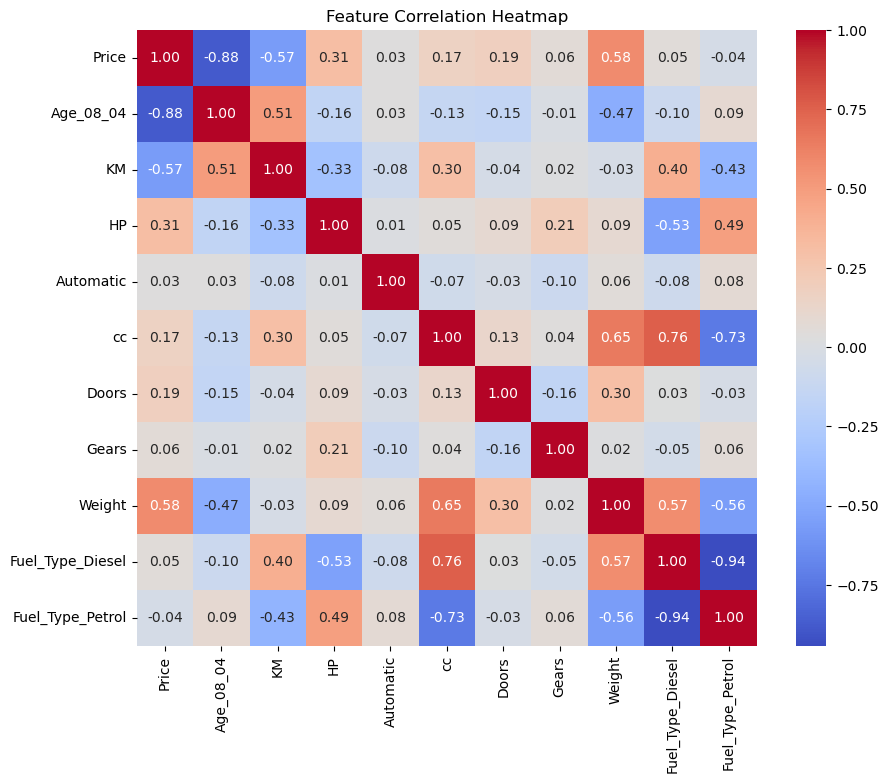

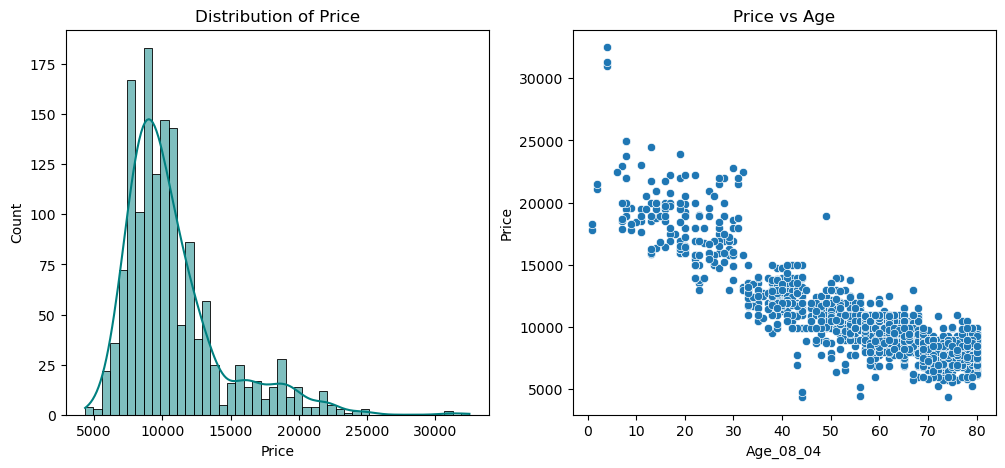

In [33]:
# Visualization: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.savefig("correlation_heatmap.png")

# Visualization: Price Distribution and Price vs Age
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Price'], kde=True, color='teal')
plt.title("Distribution of Price")

plt.subplot(1, 2, 2)
sns.scatterplot(x='Age_08_04', y='Price', data=df)
plt.title("Price vs Age")
plt.savefig("eda_plots.png")

In [6]:
df.drop('Cylinders',axis=1, inplace=True)

In [7]:
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,5,1170
...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,5,1015


In [9]:
#fix outlier
df.loc[df['cc'] == 16000, 'cc'] = 1600

In [11]:
df=pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

In [13]:
X = df.drop('Price', axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
def evaluate(model, X_t, y_t, label):
    predictions = model.predict(X_t)
    rmse = np.sqrt(mean_squared_error(y_t, predictions))
    r2 = r2_score(y_t, predictions)
    print(f"\n[{label}]")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.4f}")
    return r2

In [41]:
# Model 1:
model1 = LinearRegression()
model1.fit(X_train_scaled, y_train)
evaluate(model1,X_test_scaled, y_test, "Model 1 (All Features)")


[Model 1 (All Features)]
RMSE: 1428.44
R2 Score: 0.8471


0.8470757900790586

In [42]:
# Model 2:
features2 = ['Age_08_04','KM','Weight','HP']
model2 = LinearRegression().fit(X_train[features2], y_train)
evaluate(model2,X_test[features2], y_test, "Model 2 (All Features)")


[Model 2 (All Features)]
RMSE: 1411.85
R2 Score: 0.8506


0.8506068681500583

In [43]:
# Model 3:
features3 = ['Age_08_04', 'KM', 'Weight', 'HP', 'Gears']
model3 = LinearRegression().fit(X_train[features3], y_train)
evaluate(model3, X_test[features3], y_test, "Model 3 (Extended Key Features)")


[Model 3 (Extended Key Features)]
RMSE: 1405.63
R2 Score: 0.8519


0.851920895674205

In [44]:
#lasso and Ridge
lasso = Lasso(alpha=1.0).fit(X_train_scaled, y_train)
ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)
evaluate(lasso, X_test_scaled, y_test, "Lasso Regression")
evaluate(ridge, X_test_scaled, y_test, "Ridge Regression")


[Lasso Regression]
RMSE: 1430.62
R2 Score: 0.8466

[Ridge Regression]
RMSE: 1429.23
R2 Score: 0.8469


0.8469060632955224

In [45]:
#Coefficient Interpretation
coef_df = pd.DataFrame({'Feature': X.columns, 'Coef': model1.coef_}).sort_values(by='Coef')
print("\n--- Model Coefficients (Scaled) ---")
print(coef_df)


--- Model Coefficients (Scaled) ---
            Feature         Coef
0         Age_08_04 -2247.727898
4                cc  -596.234691
1                KM  -582.244177
5             Doors   -24.417989
3         Automatic    48.019076
6             Gears    94.777566
9  Fuel_Type_Petrol   431.037203
2                HP   616.789362
8  Fuel_Type_Diesel   645.157711
7            Weight  1272.082700


1. What is Normalization & Standardization and how is it helpful?

Normalization:- Squishes everything into a range from 0 to 1. It’s great when your data doesn't follow a classic bell curve.


Standardization:- Centers data around 0 with a standard deviation of 1. It’s usually the "go-to" for regression because it handles outliers much better.

2. What techniques can be used to address multicollinearity?

Feature Selection: Dropping one of the redundant variables (e.g., if Age and KM are 95% correlated, keep only one).

Ridge/Lasso Regression: These regularization techniques add a penalty term to the loss function, which helps manage the impact of correlated variables.

3. Assumptions & Real-World Impacts

Multicollinearity: We know Age and KM are linked. The catch: While the model still predicts price well, it becomes harder to say exactly how much just the mileage (and not the age) is affecting the price.

Independent Errors: We assume each car's data is independent. The catch: If a certain batch of cars had a factory defect, their errors would be linked, which can throw off the model's reliability.